## Personalized AI Quizzes: An A/B test on an EdTech platform

---
### 1. Introduction & Objective

This is an A/B test on an online learning platform that offers lectures, question banks, problem sets, and quizzes to college students. The feature under test is a personalized AI quiz that assembles each student's questions from what they previously got wrong, what they bookmarked, and which lectures they re-watched.

About 65,000 users were randomly assigned to one of two arms. The control group sees the standard quiz. The treatment group (`personalized_quiz`) gets the AI-generated one built from their own history. The experiment ran from June 9 through June 15, 2026.

The primary metric is the **quiz attempt rate**, the share of users in each arm who started at least one quiz. Two guardrails come with it: the **completion rate** among users who started a quiz, and **7-day retention**.

A quiz assembled from your own mistakes is by construction a harder quiz. It could pull more students in and then lose them partway through, which would register as a win on the primary metric while making the product worse. The guardrails are there to catch that.

$H_0$: the attempt rate is the same in both arms.
$H_1$: the attempt rate differs between arms.

Significance level is $\alpha = 0.05$. Users are assumed to have been enrolled at the start of the experiment window.

---
### 2. Data Loading & First Look

One row per user. Before running any tests, it's worth understanding what each column holds, how much is missing, and whether anything in here is broken.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chisquare
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/edtech_quiz_experiment.csv")

In [3]:
df.shape

(64928, 15)

In [4]:
df.head()

,user_id,variant,created_at,subscription_tier,platform,primary_subject,signup_source,questions_attempted_total,bookmarks_count,lectures_repeated,sessions_last_28d,quizzes_started,quizzes_completed,avg_quiz_score,last_active_at
0,5d6d9221-d571-435b-90ba-61bf41fba53c,control,2026-03-24 15:32:55,free,web,Physics,social,105,7,4,6.0,2,1,95.2,2026-06-12 17:42:33
1,3190dd34-ba41-4d5d-9756-cb7fa6819023,control,2025-04-06 12:34:21,premium,web,Chemistry,organic,136,8,3,5.0,2,2,73.1,2026-06-05 07:20:13
2,d604fd36-bdee-4177-beb5-669e482f2354,personalized_quiz,2025-12-17 20:58:22,free,ios,Chemistry,referral,57,1,2,2.0,1,1,60.0,2026-05-09 01:47:43
3,4d57ded0-ae1c-4d0e-980e-4326d5e09019,control,2025-06-16 01:01:25,free,web,Chemistry,paid_ads,174,14,12,10.0,4,3,90.0,2026-06-15 11:27:56
4,6959ad91-89cd-4849-a96e-1349b82295ab,personalized_quiz,2025-05-28 22:10:26,free,web,Chemistry,social,104,8,0,1.0,1,1,65.3,2026-06-06 18:46:58


In [5]:
df.shape

(64928, 15)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64928 entries, 0 to 64927
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    64928 non-null  str    
 1   variant                    64928 non-null  str    
 2   created_at                 64928 non-null  str    
 3   subscription_tier          64928 non-null  str    
 4   platform                   64928 non-null  str    
 5   primary_subject            64928 non-null  str    
 6   signup_source              64064 non-null  str    
 7   questions_attempted_total  64928 non-null  int64  
 8   bookmarks_count            64928 non-null  int64  
 9   lectures_repeated          64928 non-null  int64  
 10  sessions_last_28d          62965 non-null  float64
 11  quizzes_started            64928 non-null  int64  
 12  quizzes_completed          64928 non-null  int64  
 13  avg_quiz_score             35967 non-null  float64
 14  l

---
### 3. Data Cleaning

#### Missing values

`signup_source` is missing for about 900 users. It only feeds segmentation, and not a segment central to the analysis, so I'm leaving it.

`sessions_last_28d` has roughly 2,000 missing, which reads like a logging gap. It isn't one of the metrics being tested, so it stays as is.

`avg_quiz_score` is missing wherever a user completed nothing. That's expected behavior rather than a data problem, since there's no score to record if no quiz was finished.

`last_active_at` is missing for about 2,400 users, and the missingness is not random, it concentrates among disengaged users. Those users are treated as not retained, which is the conservative reading.

In [7]:
df.isna().sum()

user_id                          0
variant                          0
created_at                       0
subscription_tier                0
platform                         0
primary_subject                  0
signup_source                  864
questions_attempted_total        0
bookmarks_count                  0
lectures_repeated                0
sessions_last_28d             1963
quizzes_started                  0
quizzes_completed                0
avg_quiz_score               28961
last_active_at                2394
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(37)

#### Impossible values

Some rows record more completed quizzes than started, which is impossible. These are data integrity errors and are dropped.

In [9]:
df = df[df['quizzes_completed'] <= df['quizzes_started']]
df.shape

(64925, 15)

Change in shape from (64928, 15) to (64925, 15) confirms three rows were dropped.

In [10]:
# Check duplicate records
df.duplicated().sum()

np.int64(37)

In [11]:
# Remove duplicate records
df = df.drop_duplicates()

In [12]:
df.shape

(64888, 15)

After dropping duplicates, 37 rows are reduced in the shape. The final dataset contains 64,888 unique users.

---
### 4. Validity Checks

In [13]:
df['variant'].value_counts()

variant
personalized_quiz    32722
control              32166
Name: count, dtype: int64

In [14]:
df['variant'].value_counts(normalize=True)

variant
personalized_quiz    0.504284
control              0.495716
Name: proportion, dtype: float64

### Sample ratio check

The split comes out at 49.57% control and 50.43% treatment.

A chi-square test against the expected 50/50 gives the formal version of this check. Randomization that failed would invalidate every result downstream, so it comes before the metrics.

### SRM chi-square test

In [15]:
total = df.shape[0]

In [16]:
observed_counts = df['variant'].value_counts()
n_treatment = observed_counts["personalized_quiz"]
n_control = observed_counts["control"]

In [17]:
observed = [n_control, n_treatment]
expected = [total/2, total/2]
chi_stat, p_srm = chisquare(observed, expected)

In [18]:
chi_stat

np.float64(4.764147454074713)

In [19]:
p_srm

np.float64(0.029058447350366005)

A chi-square goodness-of-fit test against the expected 50/50 split gives $\chi^2 = 4.76$, $p = 0.0291$.

That p-value sits below the usual 0.05 line, but this analysis uses a stricter SRM alert threshold of $p < 0.001$ to avoid flagging very small allocation differences in a large sample. 

With ~65,000 users the test is sensitive enough that a deviation of half a percentage point will cross that bar even when nothing is wrong, so production experimentation tools set the alarm threshold closer to $p < 0.001$. At 0.0291 the split is well clear of it, and randomization holds.

### Baseline Balance Check

This is to check whether the control and treatment groups looked similar before the experiment.

In [20]:
baseline_metrics = ["questions_attempted_total", "bookmarks_count", "lectures_repeated", "sessions_last_28d"]

means = (df.groupby("variant")[baseline_metrics].mean().T)

variances = (df.groupby("variant")[baseline_metrics].var().T)

pooled_sd = np.sqrt((variances["control"] + variances["personalized_quiz"])/2)

means["standardized_differences"] = (means["personalized_quiz"] - means["control"])/pooled_sd

baseline_balance = means.reset_index(names="metric")

baseline_balance.round(3)

variant,metric,control,personalized_quiz,standardized_differences
0,questions_attempted_total,84.747,85.075,0.006
1,bookmarks_count,5.594,5.658,0.015
2,lectures_repeated,2.662,2.658,-0.002
3,sessions_last_28d,3.864,3.852,-0.004


The control and treatment groups had nearly identical behavior before the experiment. All standardized mean differences were less than 0.02, well below the 0.10 threshold commonly used to flag imbalance. This supports that randomization produced comparable groups.

---
### 5. Metric Derivation

In [21]:
df.head()

,user_id,variant,created_at,subscription_tier,platform,primary_subject,signup_source,questions_attempted_total,bookmarks_count,lectures_repeated,sessions_last_28d,quizzes_started,quizzes_completed,avg_quiz_score,last_active_at
0,5d6d9221-d571-435b-90ba-61bf41fba53c,control,2026-03-24 15:32:55,free,web,Physics,social,105,7,4,6.0,2,1,95.2,2026-06-12 17:42:33
1,3190dd34-ba41-4d5d-9756-cb7fa6819023,control,2025-04-06 12:34:21,premium,web,Chemistry,organic,136,8,3,5.0,2,2,73.1,2026-06-05 07:20:13
2,d604fd36-bdee-4177-beb5-669e482f2354,personalized_quiz,2025-12-17 20:58:22,free,ios,Chemistry,referral,57,1,2,2.0,1,1,60.0,2026-05-09 01:47:43
3,4d57ded0-ae1c-4d0e-980e-4326d5e09019,control,2025-06-16 01:01:25,free,web,Chemistry,paid_ads,174,14,12,10.0,4,3,90.0,2026-06-15 11:27:56
4,6959ad91-89cd-4849-a96e-1349b82295ab,personalized_quiz,2025-05-28 22:10:26,free,web,Chemistry,social,104,8,0,1.0,1,1,65.3,2026-06-06 18:46:58


In [22]:
df['attempted'] = (df['quizzes_started'] > 0)

In [23]:
df['attempted'].value_counts()

attempted
True     39825
False    25063
Name: count, dtype: int64

In [24]:
df['completed'] = (df['quizzes_completed'] > 0)

In [25]:
df['completed'].value_counts()

completed
True     35946
False    28942
Name: count, dtype: int64

This leaves 39,825 quiz attempts and 35,946 completed quizzes.

### Retention Phase

Using the observation window end date of June 15, users active from June 9 through June 15 are classified as active in the final seven days.

In [26]:
df["last_active_at"] = pd.to_datetime(df["last_active_at"])

window_start = pd.Timestamp("2026-06-09")

window_end = pd.Timestamp("2026-06-15")

df["retained"] = df["last_active_at"].between(window_start, window_end, inclusive="both")

In [27]:
df["retained"].sum()

np.int64(19759)

Thus, 19,759 people were retained (were active in the last 7 days)

---
### 6. Power Analysis / Experiment Design

Power analysis evaluates whether the experiment had enough users to detect a meaningful change in the primary metric.

Since the experiment is already complete, this section is retrospective. Normally these calculations are done before launch. It reports:

1. The sample size required to detect a 2 percentage-point lift.
2. The smallest effect detectable with the actual sample size.

In [28]:
control_users = len(df[df['variant'] == "control"])
control_attempts = len(df[(df['attempted']) & (df['variant'] == "control")])
baseline_rate = control_attempts / control_users
print(f"The baseline attempt rate is {baseline_rate:.1%}")

The baseline attempt rate is 59.8%


#### Analysis assumptions

- Baseline attempt rate: 59.8%
- Minimum meaningful lift: 2 percentage points
- Significance level: 5%
- Statistical power: 80%
- Allocation ratio: approximately 1:1

#### Required sample size

First, calculating how many users would have been required in each group to detect an increase 2 pp (from 59.8% to 61.8%).

In [29]:
target_rate = baseline_rate + 0.02
effect_size = proportion_effectsize(baseline_rate, target_rate)

required_sample = NormalIndPower().solve_power(effect_size=effect_size, power=0.80, alpha=0.05, ratio=1, alternative="two-sided")

print(f"Required users per group are {np.ceil(required_sample):,.0f}")

Required users per group are 9,351


Approximately **9,351 users per group** were required. The experiment had over 32,000 users per group, so it exceeded this requirement.

#### Minimum detectable effect

In [30]:
treatment_users = len(df[df["variant"] == "personalized_quiz"])
actual_ratio = treatment_users / control_users

mde_effect = NormalIndPower().solve_power(effect_size=None, nobs1=control_users, power=0.80, alpha=0.05, ratio=actual_ratio, alternative="two-sided")

detectable_rate = np.sin(np.arcsin(np.sqrt(baseline_rate)) + mde_effect / 2) ** 2
mde = detectable_rate - baseline_rate

print(f"Minimum detectable effect: {mde:.2%}")
print(f"Smallest detectable attempt rate: {detectable_rate:.2%}")

Minimum detectable effect: 1.08%
Smallest detectable attempt rate: 60.89%


With the actual sample size, the experiment could reliably detect an attempt-rate difference of approximately **1.1 percentage points** with 80% power.

---
### 7. Primary Metric Analysis
#### Attempt and completion rates

Attempt rate is measured across every user in the arm. Completion rate is measured only among users who actually started a quiz, since a user who never opened one can't be said to have abandoned it. Some data points were established above (control users, attempt rate) but are derived again below to present key metric data points together.

In [31]:
total_users = df['user_id'].count()
control_users = len(df[df['variant'] == "control"])
treatment_users = len(df[df['variant'] == "personalized_quiz"])

In [32]:
control_attempts = len(df[(df['attempted']) & (df['variant'] == "control")])
control_completes = len(df[(df['completed']) & (df['variant'] == "control")])

treatment_attempts = len(df[(df['attempted']) & (df['variant'] == "personalized_quiz")])
treatment_completes = len(df[(df['completed']) & (df['variant'] == "personalized_quiz")])

In [33]:
control_attempt_rate = control_attempts / control_users
control_complete_rate = control_completes / control_attempts

treatment_attempt_rate = treatment_attempts / treatment_users
treatment_complete_rate = treatment_completes / treatment_attempts

In [34]:
print(f"Control attempt rate is {control_attempt_rate:.1%}")
print(f"Control complete rate is {control_complete_rate:.1%}")

Control attempt rate is 59.8%
Control complete rate is 91.3%


In [35]:
print(f"Treatment attempt rate is {treatment_attempt_rate:.1%}")
print(f"Treatment complete rate is {treatment_complete_rate:.1%}")

Treatment attempt rate is 62.9%
Treatment complete rate is 89.3%


In [36]:
print(f"While attempt rate jumps {(treatment_attempt_rate - control_attempt_rate):.1%}, completion rate drops {(control_complete_rate - treatment_complete_rate):.1%}")

While attempt rate jumps 3.1%, completion rate drops 2.0%


---
### Testing the primary metric

Both metrics are proportions, so the appropriate test is a two-proportion z-test. It measures how far the observed gap between arms sits from zero, expressed in standard errors:

$$z = \frac{\hat{p}_1 - \hat{p}_2}{SE}$$

If the gap is large relative to the noise, the z-score is large and the p-value is small, which is the evidence against $H_0$.

In [37]:
count = (treatment_attempts, control_attempts)
nobs = (treatment_users, control_users)
z_stat, p_value = proportions_ztest(count, nobs)

In [38]:
if p_value < 0.001:
    print(f"z = {z_stat:.1f}, p < 0.001")
else:
    print(f"z = {z_stat:.1f}, p = {p_value:.4f}")

z = 8.1, p < 0.001


**Primary metric - attempt rate:** jumps from 59.8% to 62.9% (+3.1pp).

Two-proportion z-test: z = 8.1, p < 0.001, which is statistically significant. We reject the null, the lift is real.

### 95% confidence interval

The p-value tells us whether the difference is statistically significant, while the confidence interval estimates the likely size of the treatment effect.

In [39]:
attempt_ci = confint_proportions_2indep(count1=treatment_attempts, nobs1=treatment_users, count2=control_attempts, nobs2=control_users, method="wald")
print(f"95% confidence interval: {attempt_ci[0]:.2%} to {attempt_ci[1]:.2%}")

95% confidence interval: 2.35% to 3.85%


The personalized quiz increased the attempt rate by approximately 3.1 percentage points. The 95% confidence interval suggests that the true lift is likely between approximately 2.35 and 3.85 percentage points.

Because the entire interval is above zero, the result supports a real positive treatment effect rather than random variation.

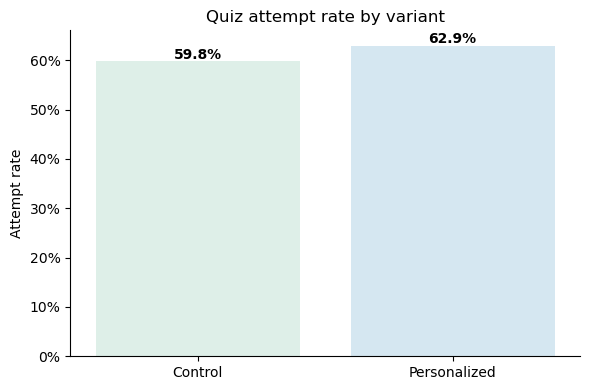

In [40]:
plot_df = pd.DataFrame({
    'variant': ['Control', 'Personalized'],
    'attempt_rate': [control_attempt_rate, treatment_attempt_rate]
})

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=plot_df, x='variant', y='attempt_rate', hue='variant',
            palette=["#dbf2e8", "#d0e8f6"], ax=ax, legend=False)

ax.set_ylabel('Attempt rate')
ax.set_xlabel('')
ax.set_title('Quiz attempt rate by variant')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

for i, r in enumerate(plot_df['attempt_rate']):
    ax.text(i, r + 0.005, f'{r:.1%}', ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

---
### 8. Guardrail Analysis

#### 8.1 Completion rate among quiz starters

The primary metric showed whether personalization increased quiz attempts. This guardrail checks whether users who started a quiz were still likely to complete it.

In [41]:
## Two-proportion z-test for guardrail 1: Completion Rate

c_count = (treatment_completes, control_completes)
c_nobs = (treatment_attempts, control_attempts)

comp_z_stat, comp_p_value = proportions_ztest(c_count, c_nobs)

In [42]:
comp_z_stat

np.float64(-6.794412967109639)

In [43]:
comp_p_value

np.float64(1.0875444615787683e-11)

##### 8.2 Quiz Completion rate

While personalized quizzes increased engagement by +3.1pp, they reduced completion rates from 91.3% to 89.3% (-2.0 pp). 

One possible explanation is that personalized quizzes contained more difficult content, but this cannot be confirmed from the available data.

Two-proportion z test reveals z-value = -6.79, p < 0.001, statistically significant. Thus we reject the null, the difference is significant.

**Note:** The groups were entered as treatment first and control second. Therefore, the negative z-score means the treatment completion rate was lower than the control completion rate.

In [44]:
comp_ci = confint_proportions_2indep(count1=treatment_completes, nobs1=treatment_attempts, count2=control_completes, nobs2=control_attempts, method="wald")
print(f"95% confidence interval: {comp_ci[0]:.2%} to {comp_ci[1]:.2%}")

95% confidence interval: -2.60% to -1.44%


The treatment group had a lower completion rate among users who started a quiz. The negative z-statistic, very small p-value, and confidence interval below zero indicate that this decline is statistically significant.

#### Overall Completion Rate

In [45]:
overall_completion = df['completed'].mean()
print(f"Overall completion rate is {overall_completion:.1%}")

Overall completion rate is 55.4%


In [46]:
control_overall_completion_rate = control_completes / control_users
treatment_overall_completion_rate = treatment_completes / treatment_users
print(f"Control overall completion rate: {control_overall_completion_rate:.1%}")
print(f"Treatment overall completion rate: {treatment_overall_completion_rate:.1%}")
print(f"Difference: {treatment_overall_completion_rate - control_overall_completion_rate:.1%}")

Control overall completion rate: 54.6%
Treatment overall completion rate: 56.2%
Difference: 1.6%


In [47]:
overall_count = (treatment_completes, control_completes)
overall_nobs = (treatment_users, control_users)
overall_z_stat, overall_p_value = proportions_ztest(overall_count, overall_nobs)

overall_ci = confint_proportions_2indep(count1=treatment_completes, nobs1=treatment_users, count2=control_completes, nobs2=control_users, method="wald")

print(f"z-statistic: {overall_z_stat:.2f}")
print(f"p-value: {overall_p_value:.4g}")
print(f"95% confidence interval: {overall_ci[0]:.2%} to {overall_ci[1]:.2%}")

z-statistic: 4.00
p-value: 6.435e-05
95% confidence interval: 0.79% to 2.32%


Although treatment users who started a quiz were less likely to complete it, the treatment produced more quiz starters overall. As a result, the overall completion rate increased from approximately 54.6% in control to 56.2% in treatment, an increase of about 1.6 percentage points.

The positive confidence interval and p-value below 0.05 indicate that this overall increase is statistically significant.

#### 8.3 Retention Rate

In [48]:
control_retained = (df["retained"] & (df["variant"] == "control")).sum()
treatment_retained = (df["retained"] & (df["variant"] == "personalized_quiz")).sum()

control_retention_rate = control_retained / control_users
treatment_retention_rate = treatment_retained / treatment_users

print(f"Control retention rate: {control_retention_rate:.2%}")
print(f"Treatment retention rate: {treatment_retention_rate:.2%}")
print(f"Difference: {treatment_retention_rate - control_retention_rate:.2%}")

Control retention rate: 30.36%
Treatment retention rate: 30.54%
Difference: 0.18%


In [49]:
retention_count = (treatment_retained, control_retained)
retention_nobs = (treatment_users, control_users)
retention_z_stat, retention_p_value = proportions_ztest(retention_count, retention_nobs)

retention_ci = confint_proportions_2indep(count1=treatment_retained, nobs1=treatment_users, count2=control_retained, nobs2=control_users, method="wald")

print(f"z-statistic: {retention_z_stat:.2f}")
print(f"p-value: {retention_p_value:.4g}")
print(f"95% confidence interval: {retention_ci[0]:.2%} to {retention_ci[1]:.2%}")

z-statistic: 0.49
p-value: 0.6226
95% confidence interval: -0.53% to 0.89%


The treatment group's retention rate was **30.54%**, compared with **30.36%** for the control group, an increase of **0.18 percentage points**.

This difference was not statistically significant $p = 0.6226$. The 95% confidence interval ranged from **-0.53 to 0.89 percentage points** and included zero, so we cannot conclude that personalized quizzes changed retention.

#### The three key metrics together:

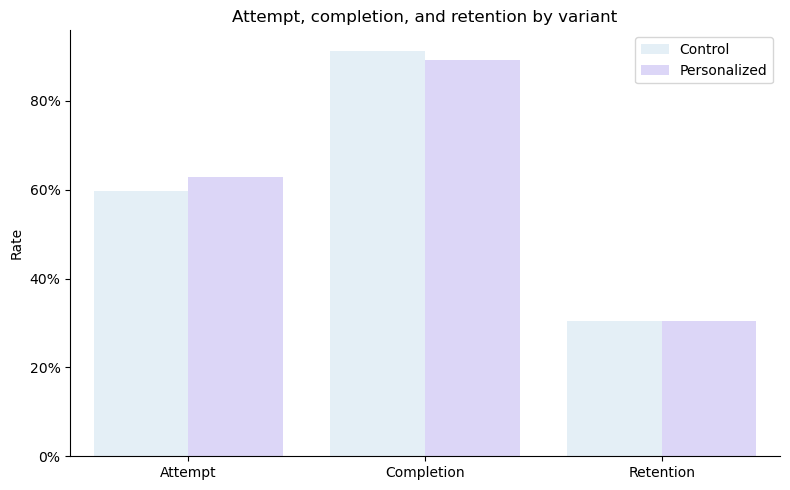

In [50]:
plot_df2 = pd.DataFrame({
    'metric':  ['Attempt', 'Attempt', 'Completion', 'Completion', 'Retention', 'Retention'],
    'variant': ['Control', 'Personalized'] * 3,
    'rate':    [control_attempt_rate, treatment_attempt_rate,
                control_complete_rate, treatment_complete_rate,
                control_retention_rate, treatment_retention_rate]
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=plot_df2, x='metric', y='rate', hue='variant',
            palette=["#e1f0f9", "#d8d0fd"], ax=ax)

ax.set_ylabel('Rate')
ax.set_xlabel('')
ax.set_title('Attempt, completion, and retention by variant')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='')
sns.despine()
plt.tight_layout()
plt.show()

Together the three metrics show the shape of the trade-off: more students start a quiz, slightly fewer of those who start finish it, and retention is unchanged. The gain is in getting users in the door, not in keeping them or in completion quality.

The next question is whether this pattern holds for everyone, or whether it depends on how much history the personalization had to work with.

---
### 9. Segment Analysis

This section tests whether the effect of personalized quizzes differed based on users' prior platform activity.

Users with fewer than 15 previously attempted questions and fewer than 3 bookmarks are classified as **low-history users**. All others are classified as **higher-history users**.

In [51]:
# Creating data frames for low-history and higher-history users
lh = df[(df["questions_attempted_total"] < 15) & (df["bookmarks_count"] < 3)]
hh = df.drop(lh.index)

In [52]:
# Counts for both user segments

lh_users = lh['user_id'].count()
lh_control_users = len(lh[lh['variant'] == "control"])
lh_treatment_users = len(lh[lh['variant'] == "personalized_quiz"])

hh_users = hh['user_id'].count()
hh_control_users = len(hh[hh['variant'] == "control"])
hh_treatment_users = len(hh[hh['variant'] == "personalized_quiz"])

In [53]:
# Low-history attempts and completes count across both variants

lh_control_attempts = len(lh[(lh['attempted']) & (lh['variant'] == "control")])
lh_control_completes = len(lh[(lh['completed']) & (lh['variant'] == "control")])

lh_treatment_attempts = len(lh[(lh['attempted']) & (lh['variant'] == "personalized_quiz")])
lh_treatment_completes = len(lh[(lh['completed']) & (lh['variant'] == "personalized_quiz")])


In [54]:
# Higher-history attempts and completes count across both variants

hh_control_attempts = len(hh[(hh['attempted']) & (hh['variant'] == "control")])
hh_control_completes = len(hh[(hh['completed']) & (hh['variant'] == "control")])

hh_treatment_attempts = len(hh[(hh['attempted']) & (hh['variant'] == "personalized_quiz")])
hh_treatment_completes = len(hh[(hh['completed']) & (hh['variant'] == "personalized_quiz")])

In [55]:
# Low-history attempt/complete rates across both variants

lh_control_attempt_rate = lh_control_attempts / lh_control_users
lh_control_complete_rate = lh_control_completes / lh_control_attempts

lh_treatment_attempt_rate = lh_treatment_attempts / lh_treatment_users
lh_treatment_complete_rate = lh_treatment_completes / lh_treatment_attempts

In [56]:
# Higher-history attempt/complete rates across both variants

hh_control_attempt_rate = hh_control_attempts / hh_control_users
hh_control_complete_rate = hh_control_completes / hh_control_attempts

hh_treatment_attempt_rate = hh_treatment_attempts / hh_treatment_users
hh_treatment_complete_rate = hh_treatment_completes / hh_treatment_attempts

In [57]:
print(f"Attempt rate for lower-history users: {lh_control_attempt_rate:.1%} to {lh_treatment_attempt_rate:.1%}")

print(f"Completion rate for lower-history users who started a quiz: {lh_control_complete_rate:.1%} to {lh_treatment_complete_rate:.1%}")

Attempt rate for lower-history users: 59.6% to 60.7%
Completion rate for lower-history users who started a quiz: 90.6% to 88.7%


In [58]:
print(f"Attempt rate for higher-history users: {hh_control_attempt_rate:.1%} to {hh_treatment_attempt_rate:.1%}")

print(f"Completion rate for higher-history users who started a quiz: {hh_control_complete_rate:.1%} to {hh_treatment_complete_rate:.1%}")

Attempt rate for higher-history users: 59.9% to 63.5%
Completion rate for higher-history users who started a quiz: 91.5% to 89.4%


Low-history Users

- For low-history users, the quiz attempt rate increased from **59.6% to 60.7%**, a lift of **1.1 percentage points**.
- However, the completion rate among users who started a quiz decreased from **90.6% to 88.7%**, a decline of **1.9 percentage points**.


High-history Users

- For higher-history users, the quiz attempt rate increased from **59.9% to 63.5%**, a lift of **3.6 percentage points**.
- However, the completion rate among users who started a quiz decreased from **91.5% to 89.4%**, a decline of **2.1 percentage points**.

In [59]:
# Low-history attempt rate test
lh_attempt_count = [lh_treatment_attempts, lh_control_attempts]
lh_attempt_nobs = [lh_treatment_users, lh_control_users]

lh_attempt_z, lh_attempt_p = proportions_ztest(lh_attempt_count, lh_attempt_nobs)
lh_attempt_ci = confint_proportions_2indep(
    count1=lh_treatment_attempts, nobs1=lh_treatment_users,
    count2=lh_control_attempts, nobs2=lh_control_users,
    method="wald"
)

print(f"Low-history attempt rate: z = {lh_attempt_z:.2f}, p = {lh_attempt_p:.4g}")
print(f"95% CI: {lh_attempt_ci[0]:.2%} to {lh_attempt_ci[1]:.2%}")

Low-history attempt rate: z = 1.25, p = 0.2106
95% CI: -0.60% to 2.74%


In [60]:
# Low-history completion rate test among starters
lh_complete_count = [lh_treatment_completes, lh_control_completes]
lh_complete_nobs = [lh_treatment_attempts, lh_control_attempts]

lh_complete_z, lh_complete_p = proportions_ztest(lh_complete_count, lh_complete_nobs)
lh_complete_ci = confint_proportions_2indep(
    count1=lh_treatment_completes, nobs1=lh_treatment_attempts,
    count2=lh_control_completes, nobs2=lh_control_attempts,
    method="wald"
)

print(f"Low-history completion rate: z = {lh_complete_z:.2f}, p = {lh_complete_p:.4g}")
print(f"95% CI: {lh_complete_ci[0]:.2%} to {lh_complete_ci[1]:.2%}")

Low-history completion rate: z = -2.67, p = 0.00765
95% CI: -3.16% to -0.48%


#### Low-History Users

For low-history users, the quiz attempt rate increased by **1.1 percentage points**, from **59.6% to 60.7%**. This change was **not statistically significant** with $p = 0.2106 > 0.05$.

The 95% CI is -0.60 to 2.74 percentage points.

Completion among users who started a quiz decreased by **1.9 percentage points**, from **90.6% to 88.7%**. This decline was **statistically significant** with $p = 0.0077 < 0.05$. 

The 95% CI is -3.16 to -0.48 percentage points.

In [61]:
# Higher-history attempt rate test
hh_attempt_count = [hh_treatment_attempts, hh_control_attempts]
hh_attempt_nobs = [hh_treatment_users, hh_control_users]

hh_attempt_z, hh_attempt_p = proportions_ztest(hh_attempt_count, hh_attempt_nobs)
hh_attempt_ci = confint_proportions_2indep(
    count1=hh_treatment_attempts, nobs1=hh_treatment_users,
    count2=hh_control_attempts, nobs2=hh_control_users,
    method="wald"
)

print(f"Higher-history attempt rate: z = {hh_attempt_z:.2f}, p = {hh_attempt_p:.4g}")
print(f"95% CI: {hh_attempt_ci[0]:.2%} to {hh_attempt_ci[1]:.2%}")

Higher-history attempt rate: z = 8.44, p = 3.13e-17
95% CI: 2.77% to 4.45%


In [62]:
# Higher-history completion rate test among starters
hh_complete_count = [hh_treatment_completes, hh_control_completes]
hh_complete_nobs = [hh_treatment_attempts, hh_control_attempts]

hh_complete_z, hh_complete_p = proportions_ztest(hh_complete_count, hh_complete_nobs)
hh_complete_ci = confint_proportions_2indep(
    count1=hh_treatment_completes, nobs1=hh_treatment_attempts,
    count2=hh_control_completes, nobs2=hh_control_attempts,
    method="wald"
)

print(f"Higher-history completion rate: z = {hh_complete_z:.2f}, p = {hh_complete_p:.4g}")
print(f"95% CI: {hh_complete_ci[0]:.2%} to {hh_complete_ci[1]:.2%}")

Higher-history completion rate: z = -6.30, p = 2.896e-10
95% CI: -2.72% to -1.44%


#### Higher-History Users

For higher-history users, the quiz attempt rate increased by **3.6 percentage points**, from **59.9% to 63.5%**. This increase was **statistically significant**, with $p < 0.001$.

The 95% confidence interval was 2.77 to 4.45 percentage points and did not include zero.

Completion among users who started a quiz decreased by **2.1 percentage points**, from **91.5% to 89.4%**. This decline was **statistically significant**, with $p < 0.001$.

The 95% confidence interval was -2.72 to -1.44 percentage points and did not include zero.

#### The Lift by History Segment

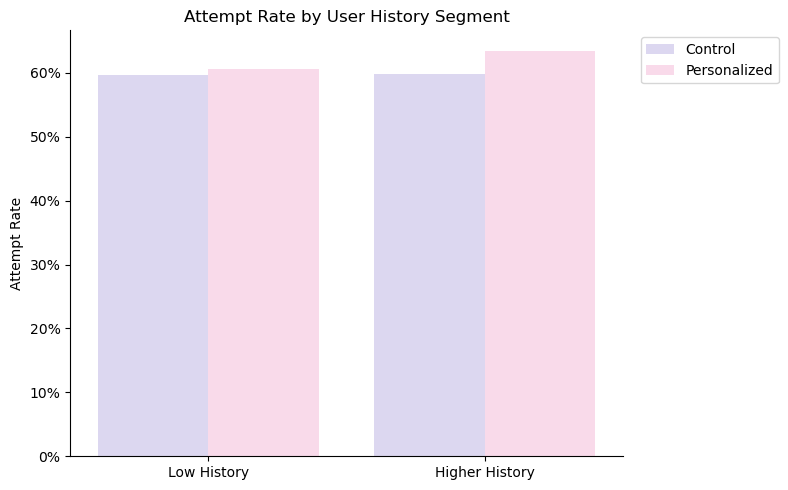

In [63]:
plot_df3 = pd.DataFrame({
    'history':  ['Low History', 'Low History', 'Higher History', 'Higher History'],
    'variant': ['Control', 'Personalized'] * 2,
    'rate':    [lh_control_attempt_rate, lh_treatment_attempt_rate,
                hh_control_attempt_rate, hh_treatment_attempt_rate]
})

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=plot_df3, x='history', y='rate', hue='variant',
            palette=["#dad3f4", "#FED5EA"], ax=ax)

ax.set_ylabel('Attempt Rate')
ax.set_xlabel('')
ax.set_title('Attempt Rate by User History Segment')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

In [64]:
plot_df3

,history,variant,rate
0,Low History,Control,0.595896
1,Low History,Personalized,0.606562
2,Higher History,Control,0.598692
3,Higher History,Personalized,0.634799


---
### 10. Robustness

Several metrics were tested (attempt, completion, overall completion, retention, plus segment splits), which raises the chance that at least one result is significant by luck. A Bonferroni correction would divide the 0.05 threshold across tests; the primary attempt-rate result, at p < 0.001, survives it comfortably.

Variance on these estimates could be reduced with CUPED, using pre-experiment covariates such as `sessions_last_28d` and `questions_attempted_total` to tighten the confidence intervals. That isn't applied here but would be the natural next step in a production setting.

A novelty effect, where a new feature draws attention that fades over time, cannot be ruled out. Detecting it would require per-day activity within the experiment window, which this user-level dataset does not carry.

---
### 11. Limitations

- The dataset contains one aggregated row per user rather than event-level activity, so we cannot examine changes over time or determine when and why users stopped engaging.

- The attempt and completion metrics are binary. A user who completed one quiz is treated the same as a user who completed several, so the analysis does not capture engagement intensity.

- Completion among quiz starters is based only on users who chose to start after treatment assignment. It is a useful diagnostic metric, but not as strong a causal measure as completion among all assigned users.

- Retention was measured using activity during only the final seven days of the experiment, so it may not reflect long-term retention.

- The experiment primarily measured engagement. It does not establish whether personalized quizzes improved actual learning outcomes.

- The user-history segments and thresholds were selected during the analysis rather than before the experiment, so those subgroup findings should be considered exploratory.

---
### 12. Decision & Recommendation

The personalized quiz increased the attempt rate by 3.1 percentage points, a real and statistically significant lift. The concern going in was that a quiz built from a student's own mistakes would be harder and drive people to abandon it, and that did happen: completion among users who started a quiz fell by 2.0 percentage points. But because so many more users started, the overall share of users completing at least one quiz still rose by 1.6 points. More students engaged, and more finished a quiz, even though any given starter was slightly less likely to complete.

Two findings temper this. Retention did not move, so the additional engagement did not translate into users returning more often within the observed window. And the effect was concentrated almost entirely among users with prior history on the platform, who saw a 3.6-point lift, while low-history users saw only 1.1 points, which was not statistically significant. The personalization needs something to personalize from, and for newer users it has little to work with.

Taken together, this is not a straightforward ship-to-everyone. The recommendation is a targeted rollout to users with sufficient history, where the feature clearly works, paired with two pieces of follow-up work before a broader launch. First, calibrate difficulty to address the completion drop, since the goal is to challenge students without pushing them to give up. Second, design a separate cold-start approach for low-history users, since the current version does little for them. A follow-up test should then measure whether the difficulty changes recover completion and whether the engagement lift eventually shows up in retention over a longer window.